In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.style.use('fivethirtyeight') # 

In [40]:
# Input the energy data
df = pd.read_csv('https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data.csv',
                index_col=[0], parse_dates=[0])

In [41]:
# Look at the df
df.head()
df.tail()

,meter_revenue_grade_ac_output_meter_149578
measured_on,
2023-11-09 22:30:00,0.0
2023-11-09 22:45:00,0.0
2023-11-09 23:00:00,0.0
2023-11-09 23:15:00,0.0
2023-11-09 23:30:00,0.0


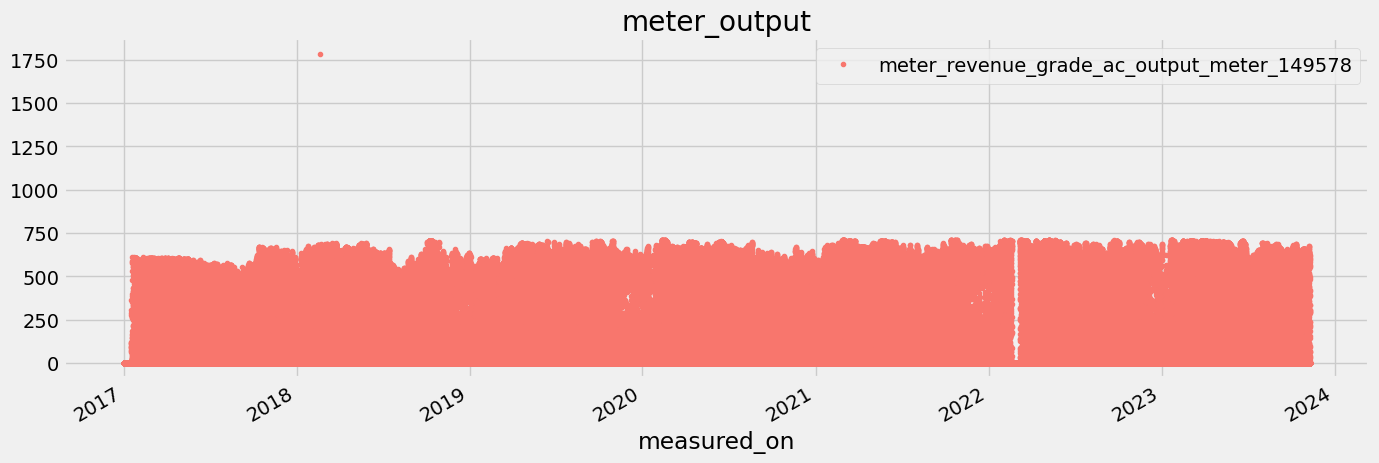

In [42]:
# Color pallete for plotting
color_pal = ["#F8766D", "#D39200", "#93AA00",
             "#00BA38", "#00C19F", "#00B9E3",
             "#619CFF", "#DB72FB"]
df.plot(style='.', figsize=(15,5), color=color_pal[0], title='meter_output')
plt.show()

In [43]:
# We creat some time series features to see how the trends are impacted by day of week, hour, time of the year.

def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    
    X = df[['hour','dayofweek','quarter','month','year',
           'dayofyear','dayofmonth']]
    if label:
        y = df[label]
        return X, y
    return X

X, y = create_features(df, label='meter_revenue_grade_ac_output_meter_149578')

features_and_target = pd.concat([X, y], axis = 1)

In [44]:
# See our features and target
features_and_target.head()

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,meter_revenue_grade_ac_output_meter_149578
measured_on,,,,,,,,
2017-01-01 00:15:00,0,6,1,1,2017,1,1,0.0
2017-01-01 00:30:00,0,6,1,1,2017,1,1,0.0
2017-01-01 00:45:00,0,6,1,1,2017,1,1,0.0
2017-01-01 01:00:00,1,6,1,1,2017,1,1,0.0
2017-01-01 01:15:00,1,6,1,1,2017,1,1,0.0


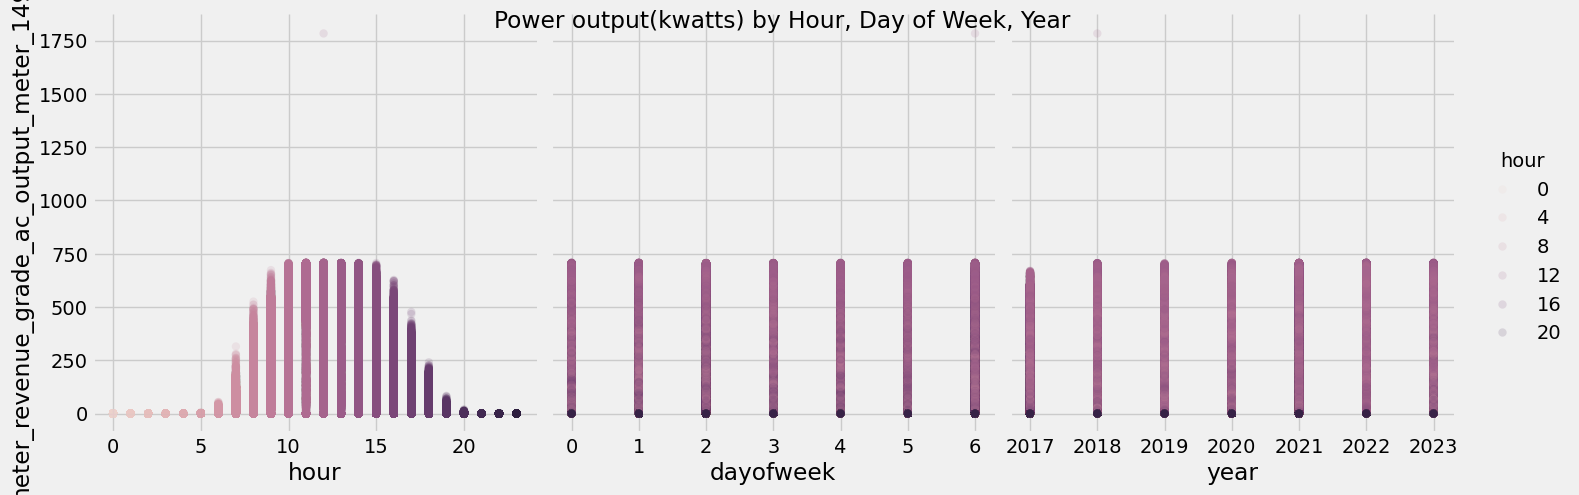

In [45]:
# Plot the features to see trends.

sns.pairplot(features_and_target.dropna(),
             hue='hour',
             x_vars=['hour','dayofweek',
                     'year'],
             y_vars='meter_revenue_grade_ac_output_meter_149578',
             height=5,
             plot_kws={'alpha':0.15, 'linewidth':0}
            )
plt.suptitle('Power output(kwatts) by Hour, Day of Week, Year')
plt.show()

In [46]:
# Train/Test Split
# We cut off the date after 2023 to use as our validation set. We will train on earlier data.
split_date = '01-Jan-2022'
df_train = df.loc[df.index <= split_date].copy()
df_test = df.loc[df.index > split_date].copy()

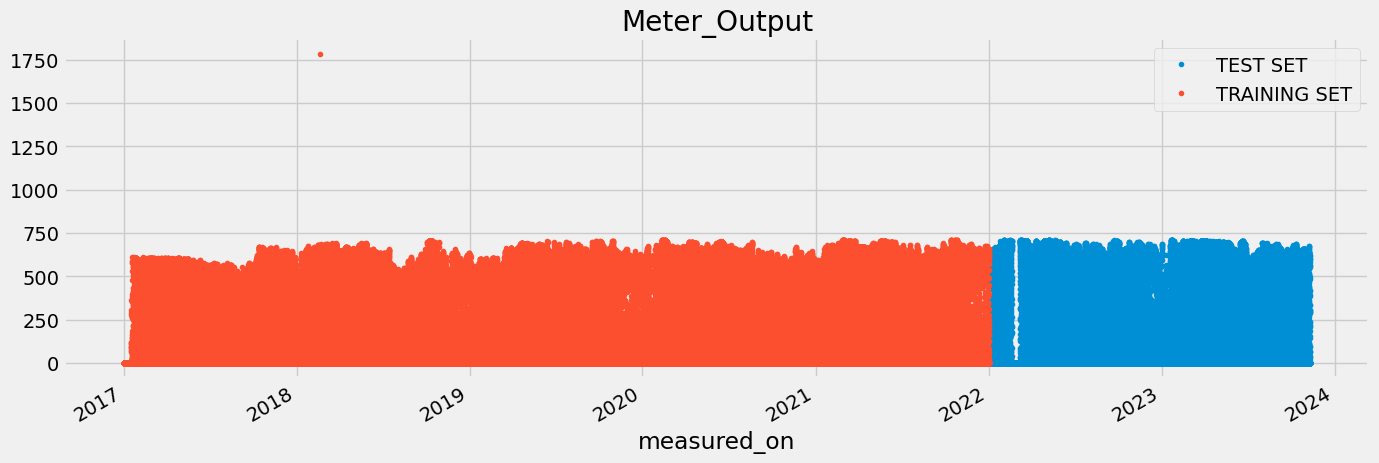

In [47]:
# Plot train and test data so we can see where we have split.
df_test \
    .rename(columns={'meter_revenue_grade_ac_output_meter_149578': 'TEST SET'}) \
    .join(df_train.rename(columns={'meter_revenue_grade_ac_output_meter_149578': 'TRAINING SET'}),
          how='outer') \
    .plot(figsize=(15,5), title='Meter_Output', style='.')
plt.show()

In [48]:
# Format data for prophet model using ds and y
df_train.reset_index() \
    .rename(columns={'measured_on':'ds',
                     'meter_revenue_grade_ac_output_meter_149578':'y'}).head()

,ds,y
0,2017-01-01 00:15:00,0.0
1,2017-01-01 00:30:00,0.0
2,2017-01-01 00:45:00,0.0
3,2017-01-01 01:00:00,0.0
4,2017-01-01 01:15:00,0.0


In [49]:
# Setup and train model and fit
model = Prophet()
model.fit(df_train.reset_index() \
              .rename(columns={'measured_on':'ds',
                               'meter_revenue_grade_ac_output_meter_149578':'y'}))

11:01:36 - cmdstanpy - INFO - Chain [1] start processing
11:01:55 - cmdstanpy - INFO - Chain [1] done processing


In [50]:
# Predict on training set with model
df_test_fcst = model.predict(df=df_test.reset_index() \
                                   .rename(columns={'measured_on':'ds'}))

In [51]:
df_test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-01-01 00:15:00,154.956796,-201.372743,40.375053,154.956796,154.956796,-235.731263,-235.731263,-235.731263,-157.390710,...,-4.435322,-4.435322,-4.435322,-73.905231,-73.905231,-73.905231,0.0,0.0,0.0,-80.774467
1,2022-01-01 00:30:00,154.956526,-201.963317,42.874258,154.956526,154.956526,-236.965223,-236.965223,-236.965223,-158.635646,...,-4.423926,-4.423926,-4.423926,-73.905652,-73.905652,-73.905652,0.0,0.0,0.0,-82.008697
2,2022-01-01 00:45:00,154.956257,-204.437850,41.977234,154.956257,154.956257,-237.347069,-237.347069,-237.347069,-159.031689,...,-4.409311,-4.409311,-4.409311,-73.906070,-73.906070,-73.906070,0.0,0.0,0.0,-82.390812
3,2022-01-01 01:00:00,154.955987,-214.308350,33.607598,154.955987,154.955987,-236.827057,-236.827057,-236.827057,-158.529094,...,-4.391480,-4.391480,-4.391480,-73.906483,-73.906483,-73.906483,0.0,0.0,0.0,-81.871069
4,2022-01-01 01:15:00,154.955718,-205.784135,36.331325,154.955718,154.955718,-235.434538,-235.434538,-235.434538,-157.157207,...,-4.370437,-4.370437,-4.370437,-73.906894,-73.906894,-73.906894,0.0,0.0,0.0,-80.478820


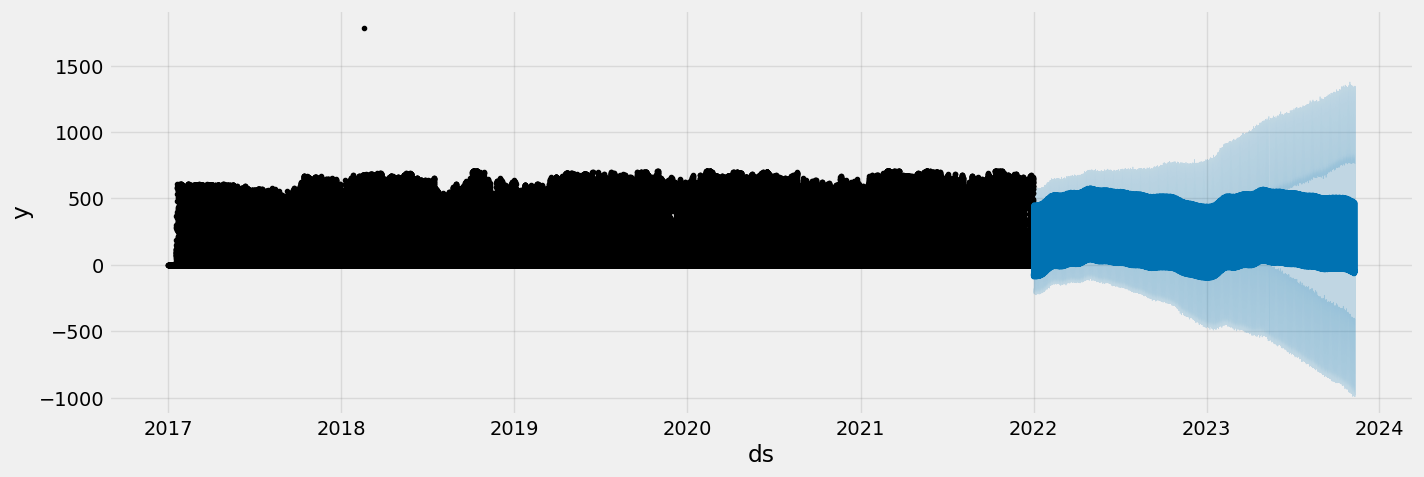

In [52]:
# Plot the forecast
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
fig = model.plot(df_test_fcst,
                 ax=ax)
plt.show()

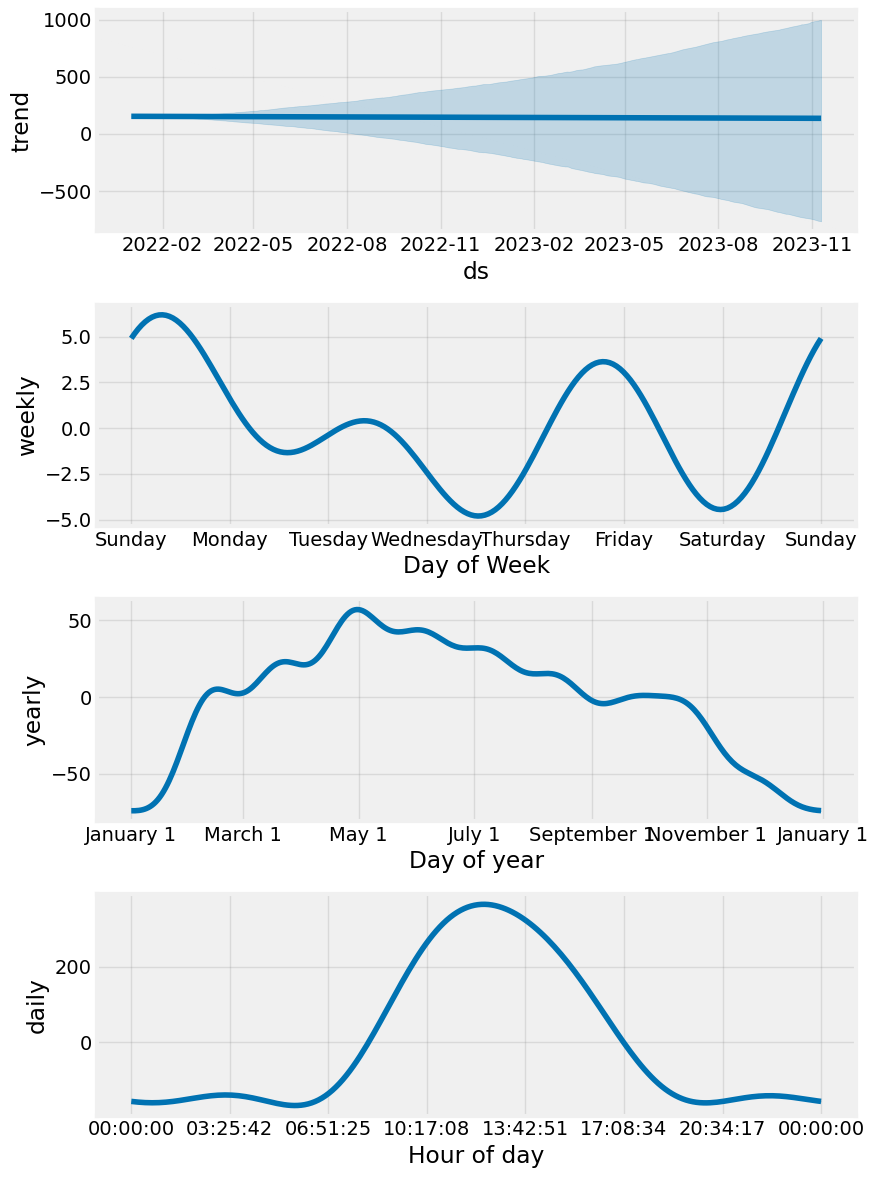

In [53]:
# Plot the components of the model
fig = model.plot_components(df_test_fcst)

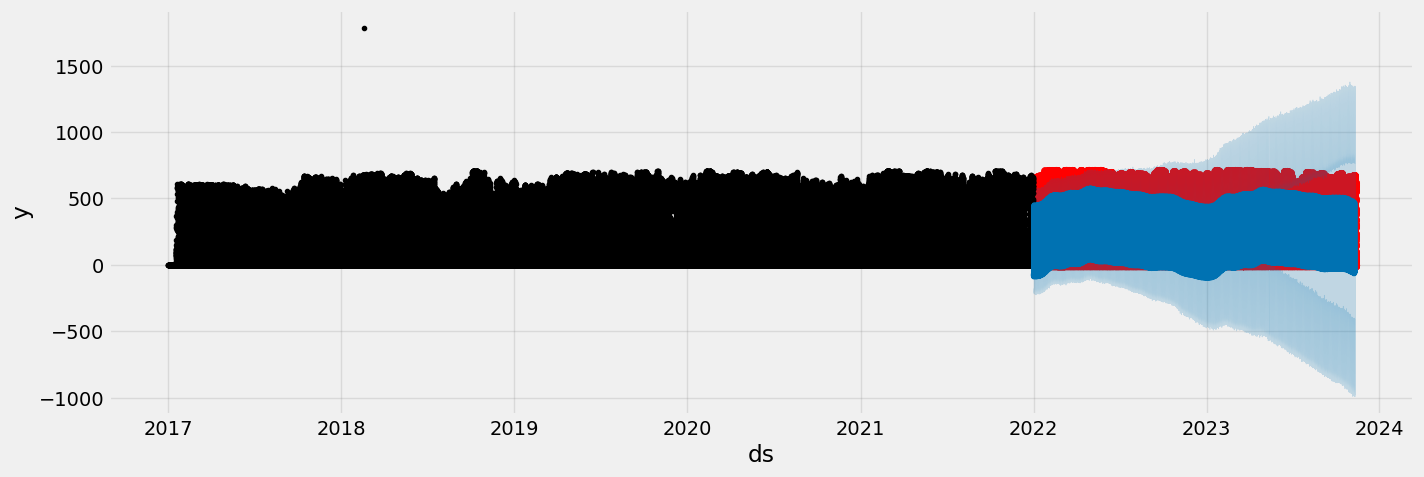

In [54]:
# Plot the forecast with the actuals
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
ax.scatter(df_test.index, df_test['meter_revenue_grade_ac_output_meter_149578'], color='r')
fig = model.plot(df_test_fcst, ax=ax)

In [55]:
mean_squared_error(y_true=df_test['meter_revenue_grade_ac_output_meter_149578'],
                   y_pred=df_test_fcst['yhat'])

11528.875257979327

In [56]:
mean_absolute_error(y_true=df_test['meter_revenue_grade_ac_output_meter_149578'],
                   y_pred=df_test_fcst['yhat'])

71.52698217771477

Error Metrics

Our RMSE error is 11528.875257979327



Our MAE error is 71.52698217771477
